# I will be working on a general project
"""
Dataset: titanic dataset,
I will modelling the survival of individuals based on the data given
"""


In [94]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import f1_score, confusion_matrix
import seaborn as sn

In [8]:
df = pd.read_csv("C:/Users/stepm/Documents/DataSets/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
print(x.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       714 non-null    float64
 3   Fare      891 non-null    float64
 4   Embarked  889 non-null    object 
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 48.9+ KB
None


In [20]:
df.fillna(value={
    'Age':df['Age'].median()
}, inplace=True)

In [21]:
df.dropna(subset=['Embarked'], inplace=True)

In [22]:
print(x.info())

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    889 non-null    int64  
 1   Sex       889 non-null    object 
 2   Age       889 non-null    float64
 3   Fare      889 non-null    float64
 4   Embarked  889 non-null    object 
 5   SibSp     889 non-null    int64  
 6   Parch     889 non-null    int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 55.6+ KB
None


In [35]:
df.drop_duplicates(inplace=True)

In [36]:
print(x.info())

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    889 non-null    int64  
 1   Sex       889 non-null    object 
 2   Age       889 non-null    float64
 3   Fare      889 non-null    float64
 4   Embarked  889 non-null    object 
 5   SibSp     889 non-null    int64  
 6   Parch     889 non-null    int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 55.6+ KB
None


# Feature Columns is the `Pclass, Sex, Age, Fare, Embarked, SibSp, Parch`

In [40]:
x = df[['Pclass', 'Sex','Age', 'Fare', 'Embarked', 'SibSp', 'Parch']]
x.head()

,Pclass,Sex,Age,Fare,Embarked,SibSp,Parch
0,3,male,22.0,7.2500,S,1,0
1,1,female,38.0,71.2833,C,1,0
2,3,female,26.0,7.9250,S,0,0
3,1,female,35.0,53.1000,S,1,0
4,3,male,35.0,8.0500,S,0,0


# Target Columns is the `Survived`

In [41]:
y = df['Survived']

# Lets visualize some columns and see how they relate to the target variable

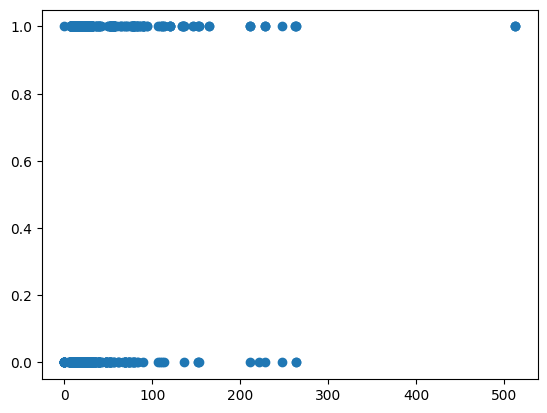

In [42]:
plt.scatter(df["Fare"], y)

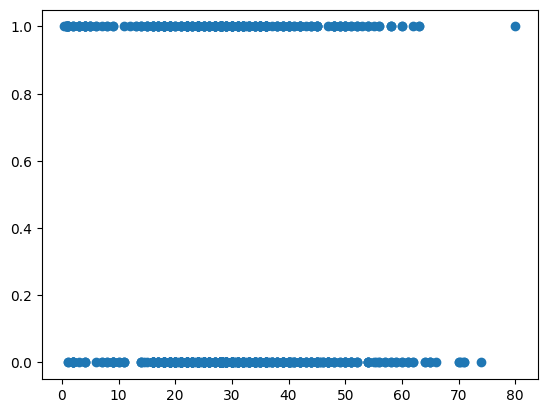

In [54]:
plt.scatter(df["Age"], y)

# Perform Data Preporcessing
<ol>
    <li>Categorical Feature encoding(OneHotEncoder)</li>    
    <li>Numerical Feature Scaling (StandardScaler)</li>
</ol>

In [25]:
transformer = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(), ['Embarked', 'Sex']),
        ('scaling', StandardScaler(), ['Pclass', 'Age', 'Fare', 'SibSp', 'Parch'])
    ])

transformed_x = transformer.fit_transform(x)

In [33]:
print(transformed_x[0:2])

[[ 0.          0.          1.          0.          1.          0.82520863
  -0.56367407 -0.50023975  0.43135024 -0.47432585]
 [ 1.          0.          0.          1.          0.         -1.57221121
   0.66921696  0.78894661  0.43135024 -0.47432585]]


# One-Hot Encoding

## Overview
**One-Hot Encoding** is a preprocessing technique used in machine learning to convert **categorical variables** (text-based categories) into **numerical features** that machine learning algorithms can understand.

Most machine learning models work with **numbers**, not text. Therefore, categories such as `"male"`, `"female"`, `"S"`, `"C"`, or `"Q"` must be converted into a numerical representation before training a model.

One-Hot Encoding solves this problem by transforming each category into a **separate binary column**.

---

# Why One-Hot Encoding Is Needed

Consider a dataset with the column:

| Passenger | Sex |
|-----------|-----|
| 1 | male |
| 2 | female |
| 3 | female |
| 4 | male |

If we convert it directly into numbers:

| Sex | Numeric |
|-----|--------|
| male | 0 |
| female | 1 |

A machine learning model might incorrectly interpret this as:
female > male


This introduces a **false ordinal relationship**, suggesting that one category is "greater" than the other.  
However, categories like `"male"` and `"female"` **do not have an inherent order**.

One-Hot Encoding avoids this issue by representing each category **independently**.

---

# How One-Hot Encoding Works

Instead of using a single column, the encoder creates **one column for each category**.

Example:

| Passenger | Sex |
|-----------|-----|
| 1 | male |
| 2 | female |
| 3 | female |
| 4 | male |

After One-Hot Encoding:

| Passenger | Sex_male | Sex_female |
|-----------|----------|------------|
| 1 | 1 | 0 |
| 2 | 0 | 1 |
| 3 | 0 | 1 |
| 4 | 1 | 0 |

### Important Rule
For each row:
- The column representing the category present gets **1**
- All other category columns get **0**

Only **one column is active (hot)** at a time, which is where the name **One-Hot Encoding** comes from.

---

# Example With Multiple Categories

Suppose we have the column `Embarked`:

| Passenger | Embarked |
|-----------|----------|
| 1 | S |
| 2 | C |
| 3 | Q |
| 4 | S |

Possible categories:

- **S** – Southampton  
- **C** – Cherbourg  
- **Q** – Queenstown  

After One-Hot Encoding:

| Passenger | Embarked_S | Embarked_C | Embarked_Q |
|-----------|------------|------------|------------|
| 1 | 1 | 0 | 0 |
| 2 | 0 | 1 | 0 |
| 3 | 0 | 0 | 1 |
| 4 | 1 | 0 | 0 |

Each category now has its **own binary column**.

---

# Properties of One-Hot Encoding

- Converts **categorical features into numerical form**
- Creates **one new column for each unique category**
- Prevents models from learning **false relationships between categories**
- Widely used in machine learning preprocessing pipelines
- Increases the **number of columns** in the dataset

---

# Example in Python (Scikit-learn)

```python
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()

encoded = encoder.fit_transform(df[['Sex']])



---
___
# Logistic Regression for Binary Classification

## Overview

**Logistic Regression** is a supervised machine learning algorithm used for **binary classification problems**, where the goal is to predict one of two possible outcomes.

Examples of binary classification problems include:

- Email: **Spam (1) or Not Spam (0)**
- Medical diagnosis: **Disease (1) or No Disease (0)**
- Customer behavior: **Churn (1) or Stay (0)**
- Titanic survival: **Survived (1) or Did Not Survive (0)**

Despite its name, Logistic Regression is primarily used for **classification**, not regression.

---

# How Logistic Regression Works

Logistic Regression predicts the **probability that a data point belongs to a class**.

It first computes a **linear combination of input features**:

z = w_0 + w_1x_1 + w_2x_2 + \dots + w_nx_n

Where:

- \(x_1, x_2, ..., x_n\) are the input features
- \(w_1, w_2, ..., w_n\) are model weights
- \(w_0\) is the bias term

This value \(z\) can be any real number, so we convert it into a probability using the **sigmoid function**.

---

# The Sigmoid Function

Logistic Regression uses the **sigmoid (logistic) function** to map values into a probability between **0 and 1**.

\sigma(z) = \frac{1}{1 + e^{-z}}

Properties of the sigmoid function:

- Output is always between **0 and 1**
- Large positive values → probability close to **1**
- Large negative values → probability close to **0**

---

# Making the Final Prediction

Once the probability is calculated, the model applies a **threshold** (usually 0.5):

| Probability | Prediction |
|-------------|-----------|
| ≥ 0.5 | Class **1** |
| < 0.5 | Class **0** |

Example:

| Probability | Predicted Class |
|-------------|----------------|
| 0.82 | 1 |
| 0.64 | 1 |
| 0.30 | 0 |
| 0.12 | 0 |

---

# Training the Model

During training, Logistic Regression learns the **optimal weights** by minimizing a loss function called **log loss (cross-entropy)**.

The model adjusts weights so that predicted probabilities match the true labels as closely as possible.



In [60]:
x_train, x_test, y_train, y_test = train_test_split(transformed_x, y, test_size=0.3, random_state=42)

In [69]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [89]:
model = LogisticRegressionCV(cv=skf,max_iter=10,verbose=1,solver='liblinear')

In [90]:
model.fit(x_train, y_train)

[LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear]

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished


,Cs,10
,fit_intercept,True
,cv,StratifiedKFo... shuffle=True)
,dual,False
,penalty,'l2'
,scoring,None
,solver,'liblinear'
,tol,0.0001
,max_iter,10
,class_weight,None
,n_jobs,None


# Logistic Regression  Objective and Solver Mechanics

> This markdown explains **how logistic regression works internally** and how the solvers **LBFGS, LibLinear, and SAGA** optimize the objective. Suitable for ML notes or documentation.

---

## 1. Problem Statement (Objective)

Logistic regression for binary classification learns weights \(w \in \mathbb{R}^d\) (and bias \(b\)) by minimizing the **regularized negative log-likelihood (log-loss)**:

\[
\min_{w,b}\; L(w,b)\;=\; -\frac{1}{n}\sum_{i=1}^n \big[ y_i\log p_i + (1-y_i)\log(1-p_i)\big] \;+\; \lambda R(w)
\]

Where:

- \(p_i = \sigma(w^\top x_i + b) = \frac{1}{1+e^{-(w^\top x_i + b)}}\)
- \(R(w)\) = regularizer (L2, L1, or ElasticNet)
- \(y_i \in \{0,1\}\)

**Gradient:**

\[
\nabla_w L = -\frac{1}{n}\sum_{i=1}^n (y_i - p_i) x_i \;+\; \lambda \nabla R(w)
\]

**Hessian (for L2):**

\[
H = \frac{1}{n}\sum_{i=1}^n p_i(1-p_i)\, x_i x_i^\top
\]

---

## 2. LBFGS Solver (Quasi-Newton)

- **Idea:** Limited-memory quasi-Newton; approximates inverse Hessian using last \(m\) updates.
- **Steps:**
  1. Compute gradient \(g_t\)
  2. Build Hessian approximation using stored \(s_k, y_k\)
  3. Compute search direction \(d_t = -H_t g_t\)
  4. Line search to find step size \(\alpha_t\)
  5. Update \(w_{t+1} = w_t + \alpha_t d_t\)
- **Pros:** Superlinear convergence, supports multiclass, robust.
- **Best for:** Small to medium datasets, L2 regularization.

---

## 3. LibLinear Solver (Coordinate Descent)

- **Idea:** Update one parameter at a time (coordinate descent) using primal/dual formulation.
- **Steps:**
  1. Pick coordinate \(j\)
  2. Compute partial derivative w.r.t \(w_j\)
  3. Solve 1D subproblem for \(w_j\)
  4. Cycle through all coordinates until convergence
- **Pros:** Efficient for small datasets, supports L1/L2, good for feature selection.
- **Limitations:** Not ideal for large datasets, uses one-vs-rest for multiclass.

---

## 4. SAGA Solver (Stochastic Variance-Reduced)

- **Idea:** Stochastic gradient descent with variance reduction using stored gradients.
- **Steps:**
  1. Pick a random sample \(i_t\)
  2. Compute stochastic gradient \(\nabla \ell_{i_t}(w_t)\)
  3. Form update: \( g_t = \nabla \ell_{i_t}(w_t) - \phi_{i_t} + \frac{1}{n}\sum_i \phi_i \)
  4. Update weights: \( w_{t+1} = w_t - \eta g_t \)
  5. Replace stored gradient \(\phi_{i_t} = \nabla \ell_{i_t}(w_t)\)
- **Pros:** Linear convergence for convex objectives, handles sparse and large data, supports L1/L2/ElasticNet.
- **Best for:** Large datasets, high-dimensional or sparse features.

---

## 5. Comparison

| Solver | Best For | Regularization | Memory | Convergence | Notes |
|--------|----------|----------------|--------|------------|-------|
| LBFGS  | Small–medium datasets | L2 | O(md) | Superlinear | Quasi-Newton, robust, multiclass |
| LibLinear | Small datasets, binary classification | L1, L2 | Low | Linear | Coordinate-wise, good for L1 |
| SAGA | Large-scale / sparse | L1, L2, ElasticNet | Higher | Linear | Stochastic with variance reduction, scales well |

---

## 6. Practical Tips

- **Feature scaling:** Important for LBFGS and SAGA.
- **Regularization:** `C` in scikit-learn → inverse regularization (\(\lambda \propto 1/C\)).
- **Stopping:** Increase `max_iter` or lower `tol` if convergence warnings appear.
- **Solver choice rules:**
  - LBFGS → default, small-medium datasets, L2.
  - LibLinear → small datasets, L1, binary classification.
  - SAGA → large datasets, sparse data, L1/ElasticNet.

---

## 7. Scikit-Learn Examples

```python
from sklearn.linear_model import LogisticRegression

# LBFGS
model_lbfgs = LogisticRegression(solver='lbfgs', penalty='l2', max_iter=1000, tol=1e-4)

# LibLinear
model_liblinear = LogisticRegression(solver='liblinear', penalty='l1', C=1.0, max_iter=1000)

# SAGA
model_saga = LogisticRegression(solver='saga', penalty='elasticnet', l1_ratio=0.5, C=1.0, max_iter=2000)

In [104]:
y_pred = model.predict(x_train)

In [106]:
score1 = f1_score(y_train, y_pred)
score

0.7282051282051282

In [91]:
pred_y = model.predict(x_test)
pred_y[0:2]

array([0, 1])

In [92]:
score = f1_score(y_test, pred_y)
score

0.7282051282051282

In [99]:
cm = confusion_matrix(y_test, pred_y)
cm

array([[143,  24],
       [ 29,  71]])

<Axes: >

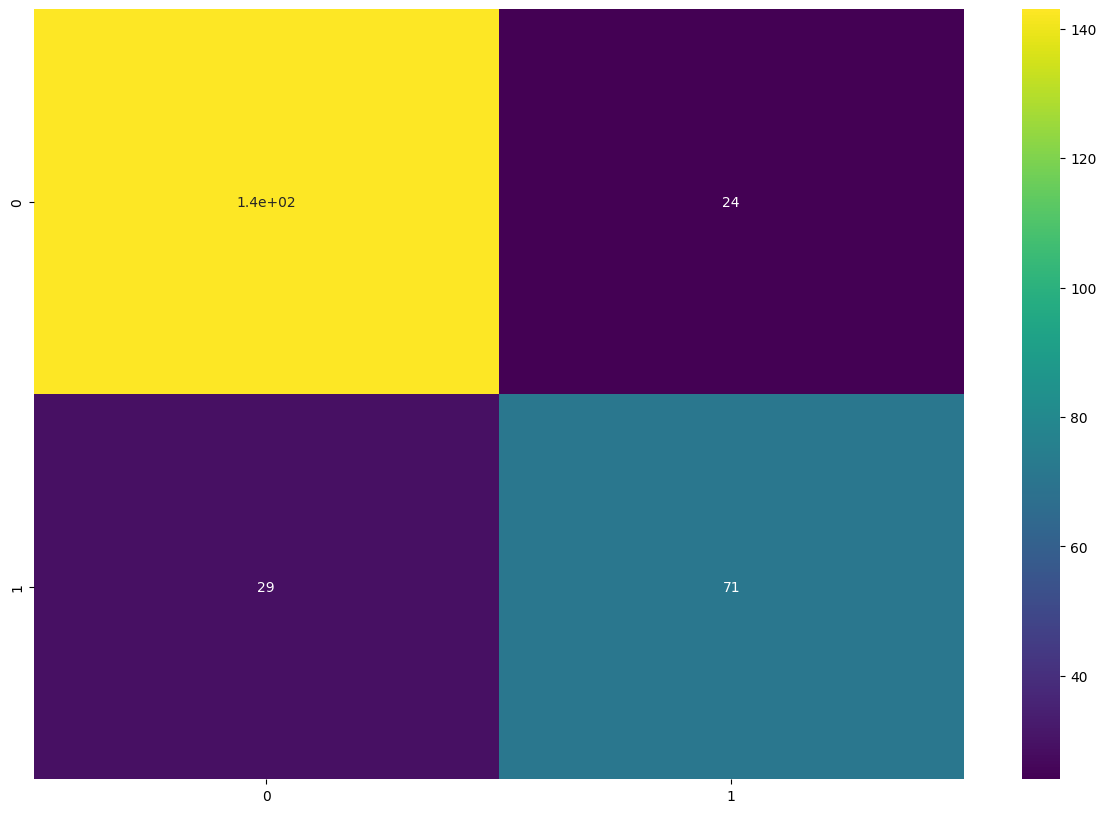

In [103]:
plt.figure(figsize=(15, 10))
sn.heatmap(cm,cmap='viridis', annot=True)